# Plotting fill-spill-merge results
a collection of ways to plot results

In [2]:
%load_ext autoreload
%autoreload 2 
import sys
sys.path.append("/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/") 

import scripts.funcs as fun

import xarray as xr
import hvplot.xarray
import numpy as np

/Users/jkingslake/Documents/science/meltwater_routing/BFRN_meltwater/python/scripts/funcs.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Start by running fill-spill-merge with a range of parameters using the gridsearch function:

In [56]:
results = fun.gridSearch(fun.fsm_xarray, x_center_of_melt = [812500.0, 817500.0], y_center_of_melt = [1930000, 1930000+5000], melt_magnitude=[0.2, 2])

  0%|          | 0/8 [00:00<?, ?it/s]

Save the results as a netcdf:
(By default some of the arrays are output by gridSearch are sparse arrays, so to save to netcdf you ned ot first convert them to dense arrays.)


In [59]:
results = results.as_numpy()
results.to_netcdf("results_5-18-24.nc")

In [31]:
results

<xarray.Dataset>
Dimensions:                       (x_center_of_melt: 2, melt_magnitude: 24,
                                   x: 1024, y: 3072, bounds_index: 4)
Coordinates:
  * x_center_of_melt              (x_center_of_melt) float64 8.125e+05 8.175e+05
  * melt_magnitude                (melt_magnitude) float64 0.2 0.4 ... 4.6 4.8
  * x                             (x) float64 8e+05 8e+05 ... 8.327e+05
  * y                             (y) float64 2e+06 2e+06 ... 1.902e+06
    spatial_ref                   int64 0
Dimensions without coordinates: bounds_index
Data variables:
    water_depth                   (y, x, x_center_of_melt, melt_magnitude) float64 ...
    dem                           (y, x, x_center_of_melt, melt_magnitude) float32 ...
    melt                          (y, x, x_center_of_melt, melt_magnitude) float32 ...
    bounds                        (bounds_index, x_center_of_melt, melt_magnitude) float64 ...
    x_center_of_mass              (x_center_of_melt, melt_magnitude) float64 ...
    y_center_of_mass              (x_center_of_melt, melt_magnitude) float64 ...
    L                             (x_center_of_melt, melt_magnitude) float64 ...
    total_GL_flux_response        (x_center_of_melt, melt_magnitude) float64 ...
    accumulation_on_grounded_ice  (x_center_of_melt, melt_magnitude) float64 ...
    melt_on_grounded_ice          (x_center_of_melt, melt_magnitude) float64 ...
    water_flow_over_GL            (x_center_of_melt, melt_magnitude) float64 ...
    grounded_mask                 (y, x, x_center_of_melt, melt_magnitude) int64 ...
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-19 18:33:21 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-19 18:33:21 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

## Plot 1: A map showing the melting region and the accumulated water depths


Coursen to make it quicker to plot

In [29]:
coarsen_x, coarsen_y = 3, 3
coarse = results.coarsen(x=coarsen_x, y=coarsen_y, boundary='trim').mean()


In [32]:
# Include contours of the DEM, a box for the melt region and a colormap for the water depths
width , height = 1000, 500

coarse.water_depth.hvplot(x ='y', y = 'x', cmap='Blues', clim=(0,1), aspect='equal').opts(framewise=False)\
    * coarse.dem.hvplot.contour(x ='y', y = 'x',levels = 40, cmap='hot', aspect='equal').opts(framewise=False)\
    * coarse.grounded_mask.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * coarse.melt.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * coarse.hvplot.scatter(x = 'y_center_of_mass', y = 'x_center_of_mass', color = 'green', size = 400, marker = '*', aspect='equal').opts(framewise=False)


BokehModel(combine_events=True, render_bundle={'docs_json': {'0db9aa17-2892-4bf3-abcc-15747af66a5f': {'version…

In [34]:
# alternatively you could crop to just the region with non-zero water depth
xmin = coarse.where(coarse.water_depth > 0, drop=True).x.min().values
xmax = coarse.where(coarse.water_depth > 0, drop=True).x.max().values
ymin = coarse.where(coarse.water_depth > 0, drop=True).y.min().values
ymax = coarse.where(coarse.water_depth > 0, drop=True).y.max().values

cropped = coarse.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))

cropped.water_depth.hvplot(x ='y', y = 'x', cmap='Blues', clim=(0,1), aspect='equal').opts(framewise=False)\
    * cropped.dem.hvplot.contour(x ='y', y = 'x',levels = 40, cmap='hot', aspect='equal').opts(framewise=False)\
    * cropped.grounded_mask.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * cropped.melt.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * cropped.hvplot.scatter(x = 'y_center_of_mass', y = 'x_center_of_mass', color = 'green', size = 400, marker = '*', aspect='equal').opts(framewise=False)

BokehModel(combine_events=True, render_bundle={'docs_json': {'1cdd803f-66f7-4455-aa64-d0515d102805': {'version…

In [116]:
# another option is to plot a colormap for the DEM and a solid color for non-zero water
cropped.dem.hvplot(x ='y', y = 'x', aspect='equal').opts(framewise=False)\
    * cropped.where(cropped.water_depth > 0.05).hvplot.image(x ='y', y = 'x', cmap='Reds', clim=(-0.1,0.1), aspect='equal').opts(framewise=False)\
    * cropped.melt.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * cropped.hvplot.scatter(x = 'y_center_of_mass', y = 'x_center_of_mass', color = 'green', size = 400, marker = '*', aspect='equal').opts(framewise=False)


BokehModel(combine_events=True, render_bundle={'docs_json': {'94668068-9e6f-4e75-bfcd-e43b653df634': {'version…

## Plot 2: a variable as a function of one parameter, for multiple otehr paremeters


In [25]:
results = fun.gridSearch(fun.fsm_xarray, x_center_of_melt = [812500.0, 817500.0], melt_magnitude=list(np.arange(0.2, 5, 0.2)))

  0%|          | 0/48 [00:00<?, ?it/s]

/Users/jkingslake/miniconda3/envs/full_py_env/lib/python3.11/site-packages/xarray/core/dataset.py:5525: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(


In [37]:
results.nbytes/1e9

3.623915864

In [38]:
results

<xarray.Dataset>
Dimensions:                       (x_center_of_melt: 2, melt_magnitude: 24,
                                   x: 1024, y: 3072, bounds_index: 4)
Coordinates:
  * x_center_of_melt              (x_center_of_melt) float64 8.125e+05 8.175e+05
  * melt_magnitude                (melt_magnitude) float64 0.2 0.4 ... 4.6 4.8
  * x                             (x) float64 8e+05 8e+05 ... 8.327e+05
  * y                             (y) float64 2e+06 2e+06 ... 1.902e+06
    spatial_ref                   int64 0
Dimensions without coordinates: bounds_index
Data variables:
    water_depth                   (y, x, x_center_of_melt, melt_magnitude) float64 ...
    dem                           (y, x, x_center_of_melt, melt_magnitude) float32 ...
    melt                          (y, x, x_center_of_melt, melt_magnitude) float32 ...
    bounds                        (bounds_index, x_center_of_melt, melt_magnitude) float64 ...
    x_center_of_mass              (x_center_of_melt, melt_magnitude) float64 ...
    y_center_of_mass              (x_center_of_melt, melt_magnitude) float64 ...
    L                             (x_center_of_melt, melt_magnitude) float64 ...
    total_GL_flux_response        (x_center_of_melt, melt_magnitude) float64 ...
    accumulation_on_grounded_ice  (x_center_of_melt, melt_magnitude) float64 ...
    melt_on_grounded_ice          (x_center_of_melt, melt_magnitude) float64 ...
    water_flow_over_GL            (x_center_of_melt, melt_magnitude) float64 ...
    grounded_mask                 (y, x, x_center_of_melt, melt_magnitude) int64 ...
Attributes:
    AREA_OR_POINT:       Area
    PROCESSING_HISTORY:  2024-05-19 18:33:21 UTC | RichDEM v2.2.9 (hash=41503...
    TIFFTAG_DATETIME:    2024-05-19 18:33:21 UTC
    TIFFTAG_SOFTWARE:    RichDEM v2.2.9 (hash=415032db2f303721, compiled=2024...
    _FillValue:          -9999.0
    scale_factor:        1.0
    add_offset:          0.0

In [39]:
results = results.as_numpy()
var1 = 'total_GL_flux_response'
var2 = 'water_flow_over_GL'
results[var].hvplot(x='melt_magnitude', y=var, by='x_center_of_melt') + results[var2].hvplot(x='melt_magnitude', y=var2, by='x_center_of_melt')
                   

:Layout
   .NdOverlay.I  :NdOverlay   [x_center_of_melt]
      :Curve   [melt_magnitude]   (total_GL_flux_response)
   .NdOverlay.II :NdOverlay   [x_center_of_melt]
      :Curve   [melt_magnitude]   (water_flow_over_GL)

In [36]:
coarsen_x, coarsen_y = 3, 3
coarse = results.coarsen(x=coarsen_x, y=coarsen_y, boundary='trim').mean()
xmin = coarse.where(coarse.water_depth > 0, drop=True).x.min().values
xmax = coarse.where(coarse.water_depth > 0, drop=True).x.max().values
ymin = coarse.where(coarse.water_depth > 0, drop=True).y.min().values
ymax = coarse.where(coarse.water_depth > 0, drop=True).y.max().values

cropped = coarse.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))

cropped.water_depth.hvplot(x ='y', y = 'x', cmap='Blues', clim=(0,1), aspect='equal').opts(framewise=False)\
    * cropped.dem.hvplot.contour(x ='y', y = 'x',levels = 40, cmap='hot', aspect='equal').opts(framewise=False)\
    * cropped.grounded_mask.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * cropped.melt.hvplot.contour(x ='y', y = 'x', levels=[0.0, 0.0], aspect='equal').opts(framewise=False)\
    * cropped.hvplot.scatter(x = 'y_center_of_mass', y = 'x_center_of_mass', color = 'green', size = 400, marker = '*', aspect='equal').opts(framewise=False)

BokehModel(combine_events=True, render_bundle={'docs_json': {'8997f383-5243-47e5-87a1-fbe6800afd82': {'version…

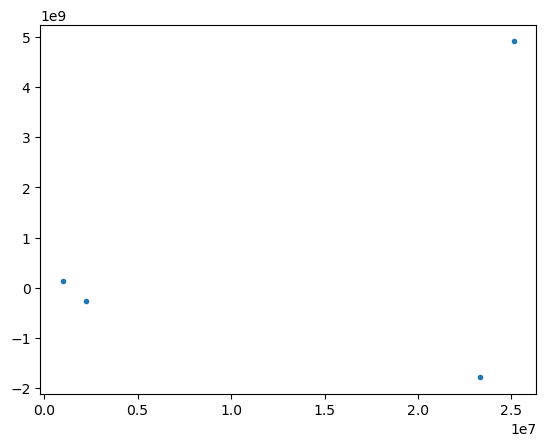

In [7]:
import matplotlib.pyplot as plt 
plt.plot(results.water_flow_over_GL.values.flatten(), results.total_GL_flux_response.values.flatten(),'.')

Now we can save the results as a netcdf. By default some of the arrays are output by gridSearch are sparse arrays, so to save to netcdf you ned ot first convert them to dense arrays. 


In [ ]:
results = results.as_numpy()
results.to_netcdf("results_small_test.nc")